# Backtest 005 — TTM Breakout Squeeze

Notebook implementation of `BreakoutTTMVersion2` from `backend/app/services/strategies/breakout_ttm.py`.

## Strategy logic

| Version | Entry condition |
|---------|----------------|
| **v1** | `no_squeeze` AND `TTM momentum > 0` |
| **v2** | `no_squeeze` AND `TTM momentum crossed above 0` (up to 3 bars look-back) |
| **v3** | Squeeze JUST released AND (`momentum > 0` OR `consecutive_neg > threshold`) OR Williams VIX Fix signal |

**Exit:** ATR trailing stop (multiplier optimised via Optuna)

**Optimisation:** Multi-objective Optuna — maximise `Total Return (%)` and `Sortino Ratio`

In [86]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.common import shift_2d, count_consecutive_neg_2d, autocorr_2d, obv_2d, ema_span_2d
from backend.app.services.indicators.kama   import kama_2d, slope_flat_2d
from backend.app.services.indicators.smart_money_flow import smart_money_flow_cloud, SMF_DEFAULTS

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [87]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'

df_raw = load_stocks()

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Shape : {close.shape}  |  {close.index[0].date()} → {close.index[-1].date()}')
print(f'Symbols: {len(valid_syms)}  |  Benchmark: {BENCHMARK}')
close.tail(3)


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 990)  |  2016-06-20 → 2026-06-19
Shape : (2501, 198)  |  2016-06-20 → 2026-06-19
Symbols: 198  |  Benchmark: VNINDEX


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-17,7.40,16.9,22.0,44.6,9.48,12.05,15.00,21.90,5.69,5.93,...,1806.20,59.0,12.85,26.5,2.93,60.5,28.15,20.25,65.5,8.88
2026-06-18,7.38,17.2,22.4,44.5,9.43,11.90,14.75,21.80,5.61,5.90,...,1830.47,59.2,12.65,26.4,2.90,60.0,30.10,19.90,65.5,8.73
2026-06-19,7.43,17.4,22.2,44.2,9.38,11.90,15.05,21.45,5.54,5.87,...,1824.53,59.0,12.65,25.9,2.89,58.9,29.35,19.20,65.0,8.64


In [88]:
IS_FRAC   = 0.6
split_idx = int(len(close) * IS_FRAC)
oos_start = close.index[split_idx]

close_is   = close.iloc[:split_idx];  close_oos  = close.iloc[split_idx:]
high_is    = high.iloc[:split_idx];   high_oos   = high.iloc[split_idx:]
low_is     = low.iloc[:split_idx];    low_oos    = low.iloc[split_idx:]
open_is    = open_.iloc[:split_idx];  open_oos   = open_.iloc[split_idx:]
volume_is  = volume.iloc[:split_idx]; volume_oos = volume.iloc[split_idx:]

print(f'IS  {close_is.index[0].date()} → {close_is.index[-1].date()}  ({len(close_is)} bars)')
print(f'OOS {close_oos.index[0].date()} → {close_oos.index[-1].date()}  ({len(close_oos)} bars)')

IS  2016-06-20 → 2022-06-15  (1500 bars)
OOS 2022-06-16 → 2026-06-19  (1001 bars)


## 2. TTM Breakout Helpers

In [89]:
def compute_signals(
    close, high, low,
    open_                     = None,   # required for SMF regime gate
    volume                    = None,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix (v3 only)
    william_vix_period:       int   = 20,
    # KAMA slope filter (v1, v2 only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
    # 5-day return autocorrelation filter (v1, v2 only)
    use_autocorr:             bool  = False,
    autocorr_ret_period:      int   = 5,
    autocorr_window:          int   = 60,
    autocorr_threshold:       float = 0.05,
    # OBV filter (v1, v2 only) — requires volume
    use_obv:                  bool  = False,
    obv_ema_period:           int   = 20,
    # Smart Money Flow Cloud regime gate (all versions) — requires open_ + volume
    use_smf:                  bool  = False,
    smf_kwargs:               dict  = None,
    smf_strength_threshold:   float = 0.0,   # gate: strength_signed > threshold
):
    """
    Compute TTM Breakout entry signals.

    Indicators are computed lazily — only what the requested version needs:
      v1, v2 : BB + Keltner (both bands) + TTM histogram + KAMA slope [+ OBV]
      v3     : BB + Keltner (upper only) + TTM histogram + WVF
      all    : SMF last_signal == +1 regime gate when use_smf=True
    """
    # ── always needed ──────────────────────────────────────────────────────────
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    close_np    = close.to_numpy()
    bb_upper_np = bb.upperband.to_numpy()
    bb_lower_np = bb.lowerband.to_numpy()
    ema_np      = ema.real.to_numpy()
    atr_np      = atr.real.to_numpy()
    kc_upper_np = ema_np + kc_multiplier * atr_np

    hh  = MAX.run(high,  timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,   timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    # ── v1 / v2 only: lower Keltner band + KAMA slope mask ────────────────────
    if entry_version in ('v1', 'v2'):
        kc_lower_np = ema_np - kc_multiplier * atr_np
        if use_kama_slope:
            kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
            flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
        else:
            flat_np = np.ones_like(close_np, dtype=np.bool_)

    # ── v3 only: Williams VIX Fix ──────────────────────────────────────────────
    elif entry_version == 'v3':
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period,
            mult=bb_multiplier,
            bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── autocorrelation filter — v1 / v2 only ─────────────────────────────────
    if entry_version in ('v1', 'v2') and use_autocorr:
        acf_np     = autocorr_2d(close_np.astype(np.float64),
                                 ret_period=autocorr_ret_period,
                                 window=autocorr_window)
        acf_filter = acf_np > autocorr_threshold
    else:
        acf_filter = np.ones_like(close_np, dtype=np.bool_)

    # ── OBV filter — v1 / v2 only, requires volume ────────────────────────────
    if entry_version in ('v1', 'v2') and use_obv and volume is not None:
        volume_np = volume.to_numpy(dtype=np.float64)
        obv_np = obv_2d(close_np.astype(np.float64), volume_np)
        obv_ema_np = ema_span_2d(obv_np, obv_ema_period)
        obv_filter = obv_np > obv_ema_np
    else:
        obv_filter = np.ones_like(close_np, dtype=np.bool_)

    # ── SMF regime gate — all versions, requires open_ + volume ───────────────
    if use_smf:
        _smf_kw = {**SMF_DEFAULTS, **(smf_kwargs or {})}
        smf_out = smart_money_flow_cloud(open_, high, low, close, volume, **_smf_kw)
        smf_bull_np = np.column_stack([
            smf_out[sym]['strength_signed'].values > smf_strength_threshold
            for sym in close.columns
        ])
    else:
        smf_bull_np = np.ones_like(close_np, dtype=np.bool_)

    # ── v1: no-squeeze + positive momentum + KAMA flat ────────────────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np & acf_filter & obv_filter & smf_bull_np
        if use_kama_slope:
            entries_np = entries_np & (close_np > kama_np)

    # ── v2: momentum zero-cross + KAMA flat ───────────────────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        cond_2 = (ttms_np > ttms_1) & crossed_1ago
        cond_3 = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np & acf_filter & obv_filter & smf_bull_np
        if use_kama_slope:
            entries_np = entries_np & (close_np > kama_np)

    # ── v3: bottom-fishing + WVF contrarian ───────────────────────────────────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        entries_np = (entry_2 | wvf_np)

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. Baseline Run (default params, entry v3)

In [90]:
# VNINDEX Buy & Hold — full-sample reference
bm_oos_idx = close.index.get_loc(oos_start) if hasattr(close.index, 'get_loc') else (close.index >= oos_start).argmax()

bm_entries_full = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
bm_entries_full.iloc[0, 0] = True
bm_exits_full   = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])

pf_bh_full = vbt.Portfolio.from_signals(
    close=close[[BENCHMARK]], entries=bm_entries_full, exits=bm_exits_full,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_total = float(pf_bh_full.total_return())
bh_sharpe = float(pf_bh_full.sharpe_ratio())
print(f'VNINDEX Buy & Hold (full)  Total Return={bh_total:.1%}  Sharpe={bh_sharpe:.3f}')


VNINDEX Buy & Hold (full)  Total Return=191.2%  Sharpe=0.806


---
## 4. Per-Version Optimisation — v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently.  v3 has extra params (`consecutive_neg_threshold`, `william_vix_period`);
v1/v2 share the same space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0` | — |
| `study_v2` | `no_squeeze & TTM crossed above 0` (±2 bars) | — |
| `study_v3` | squeeze released & (TTM>0 OR consec_neg>thr) OR WVF | `consecutive_neg_threshold`, `william_vix_period` |

In [ ]:
def make_objective(version: str):
    """
    Returns an Optuna objective fixed to `version`.
    Objectives: (Total Return %, Sortino Ratio)

    Parameter search space is version-specific:
      v1, v2 : KAMA slope params included only when use_kama_slope=True
      v3     : WVF + consecutive_neg included; KAMA params excluded
      all    : SMF cloud params included only when use_smf=True
    """
    def objective(trial):
        # ── shared across all versions ─────────────────────────────────────
        bb_window            = trial.suggest_int  ('bb_window',            10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',        0.8, 2.0, step=0.1)
        bb_matype            = trial.suggest_int  ('bb_matype',            0, 3)

        kc_window            = trial.suggest_int  ('kc_window',            20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',        0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',        5, 20)
        donichan_window      = trial.suggest_int  ('donichan_window',      8, 25)
        osc_smoothing_period = trial.suggest_int  ('osc_smoothing_period', 5, 20)

        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',    3, 20)
        atr_period           = trial.suggest_int  ('atr_period',           5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',       1.2, 3.5, step=0.1)

        # ── SMF cloud regime gate (uses SMF_DEFAULTS when enabled) ───────
        use_smf = trial.suggest_categorical('use_smf', [True, False])
        smf_kw  = None

        # ── v1 / v2 only: KAMA slope filter ───────────────────────────────
        if version in ('v1', 'v2'):
            use_kama_slope = trial.suggest_categorical('use_kama_slope', [True, False])
            if use_kama_slope:
                kama_period        = trial.suggest_int  ('kama_period',        5, 20)
                kama_fast          = trial.suggest_int  ('kama_fast',          2, 5)
                kama_slow          = trial.suggest_int  ('kama_slow',          20, 50)
                kama_slope_win     = trial.suggest_int  ('kama_slope_win',     3, 20)
                flat_threshold_pct = trial.suggest_float('flat_threshold_pct', 1.0, 3.0, step=0.1)
            else:
                kama_period        = 10
                kama_fast          = 2
                kama_slow          = 30
                kama_slope_win     = 5
                flat_threshold_pct = 1.5
            signal_kwargs = dict(
                use_kama_slope     = use_kama_slope,
                kama_period        = kama_period,
                kama_fast          = kama_fast,
                kama_slow          = kama_slow,
                kama_slope_win     = kama_slope_win,
                flat_threshold_pct = flat_threshold_pct,
            )

        # ── v3 only: WVF + consecutive neg threshold ───────────────────────
        else:
            william_vix_period        = trial.suggest_int('william_vix_period',        14, 30)
            consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold',  3, 15)
            signal_kwargs = dict(
                use_kama_slope            = False,
                william_vix_period        = william_vix_period,
                consecutive_neg_threshold = consecutive_neg_threshold,
            )

        try:
            entries = compute_signals(
                close_is, high_is, low_is,
                open_=open_is, volume=volume_is,
                bb_window            = bb_window,
                bb_multiplier        = bb_multiplier,
                bb_matype            = bb_matype,
                kc_window            = kc_window,
                kc_multiplier        = kc_multiplier,
                kc_atr_period        = kc_atr_period,
                donichan_window      = donichan_window,
                osc_smoothing_period = osc_smoothing_period,
                entry_version        = version,
                use_smf              = use_smf,
                **signal_kwargs,
            )
            exits, sl_stop_df = compute_exits(
                close_is, high_is, low_is,
                atr_multiplier    = atr_multiplier,
                atr_period        = atr_period,
                low_stop_lookback = low_stop_lookback,
            )

            pf = vbt.Portfolio.from_signals(
                close=close_is, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0

            # penalise if <30% of symbols profitable
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5

            return mean_ret, mean_sort

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 300   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n── Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ──────────────────────')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'ttm_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')

## 5. Select Best Params per Version

In [92]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':          round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,donichan_window,osc_smoothing_period,low_stop_lookback,atr_period,atr_multiplier,use_smf,use_kama_slope,william_vix_period,consecutive_neg_threshold
Version,,,,,,,,,,,,,,,,,,
v1,194,226.14,1.260,22,1.0,2,51,1.4,6,9,6,13,6,2.3,True,False,NaN,NaN
v2,267,223.53,1.255,15,1.3,3,51,1.2,20,8,7,5,18,2.3,False,False,NaN,NaN
v3,248,221.76,1.133,11,1.1,3,35,0.9,17,23,16,17,5,3.2,True,NaN,15.0,8.0


In [93]:
# Extract all optimised parameters from `summary_df` (run after optimisation cell above)
_meta_cols = {'Trial #', 'Total Return (%)', 'Sortino'}
param_cols = [c for c in summary_df.columns if c not in _meta_cols]
all_params_by_version = summary_df[param_cols].to_dict('index')

import json
print('Tunable keys ({}):'.format(len(param_cols)))
print(param_cols)
print(json.dumps(all_params_by_version, indent=2, default=str))


Tunable keys (15):
['bb_window', 'bb_multiplier', 'bb_matype', 'kc_window', 'kc_multiplier', 'kc_atr_period', 'donichan_window', 'osc_smoothing_period', 'low_stop_lookback', 'atr_period', 'atr_multiplier', 'use_smf', 'use_kama_slope', 'william_vix_period', 'consecutive_neg_threshold']
{
  "v1": {
    "bb_window": 22,
    "bb_multiplier": 1.0,
    "bb_matype": 2,
    "kc_window": 51,
    "kc_multiplier": 1.4000000000000001,
    "kc_atr_period": 6,
    "donichan_window": 9,
    "osc_smoothing_period": 6,
    "low_stop_lookback": 13,
    "atr_period": 6,
    "atr_multiplier": 2.3,
    "use_smf": true,
    "use_kama_slope": false,
    "william_vix_period": NaN,
    "consecutive_neg_threshold": NaN
  },
  "v2": {
    "bb_window": 15,
    "bb_multiplier": 1.3,
    "bb_matype": 3,
    "kc_window": 51,
    "kc_multiplier": 1.2000000000000002,
    "kc_atr_period": 20,
    "donichan_window": 8,
    "osc_smoothing_period": 7,
    "low_stop_lookback": 5,
    "atr_period": 18,
    "atr_multiplier":

In [94]:
summary_df

,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,donichan_window,osc_smoothing_period,low_stop_lookback,atr_period,atr_multiplier,use_smf,use_kama_slope,william_vix_period,consecutive_neg_threshold
Version,,,,,,,,,,,,,,,,,,
v1,194,226.14,1.260,22,1.0,2,51,1.4,6,9,6,13,6,2.3,True,False,NaN,NaN
v2,267,223.53,1.255,15,1.3,3,51,1.2,20,8,7,5,18,2.3,False,False,NaN,NaN
v3,248,221.76,1.133,11,1.1,3,35,0.9,17,23,16,17,5,3.2,True,NaN,15.0,8.0


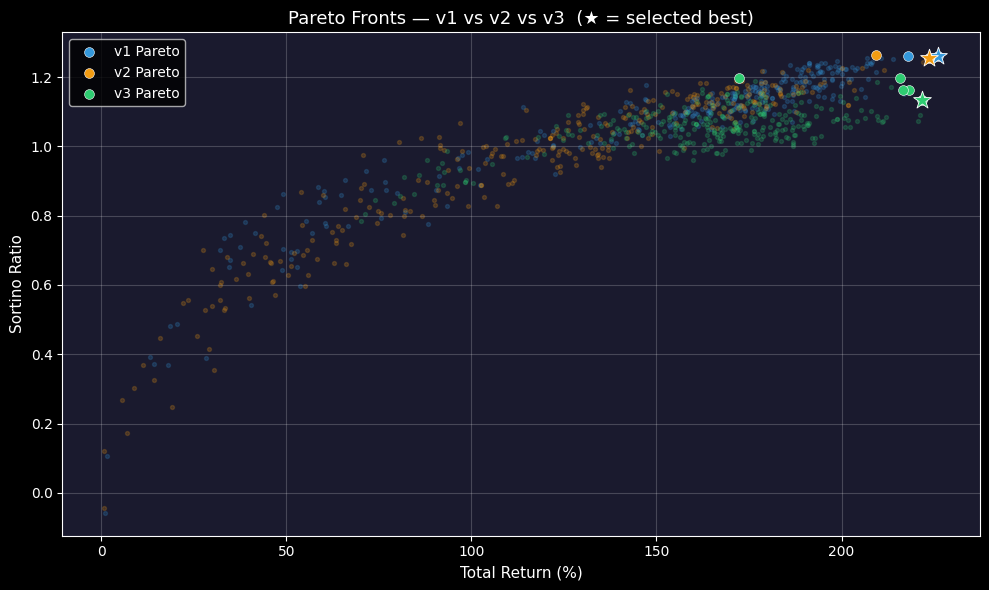

In [95]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',    fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [ ]:
# OOS evaluation — params found on IS, evaluated on held-out OOS slice.
# Baseline: VNINDEX Buy & Hold on OOS (the passive benchmark to beat).

# ── VNINDEX Buy & Hold on OOS ─────────────────────────────────────────────────
bm_entries_oos = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
bm_entries_oos.iloc[0, 0] = True
bm_exits_oos   = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])

pf_base = vbt.Portfolio.from_signals(
    close=close_oos[[BENCHMARK]], entries=bm_entries_oos, exits=bm_exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_sharpe_oos = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_ret_oos    = float(np.atleast_1d(pf_base.total_return())[0])
print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_sharpe_oos:.3f}')

# ── OOS optimised (IS params applied to OOS) ──────────────────────────────────
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} on OOS …')
    entries = compute_signals(
        close_oos, high_oos, low_oos,
        open_=open_oos, volume=volume_oos,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = p['bb_matype'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p['donichan_window'],
        osc_smoothing_period     = p['osc_smoothing_period'],
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period',        20),
        use_kama_slope           = p.get('use_kama_slope',            False),
        kama_period              = p.get('kama_period',               10),
        kama_fast                = p.get('kama_fast',                 2),
        kama_slow                = p.get('kama_slow',                 30),
        kama_slope_win           = p.get('kama_slope_win',            5),
        flat_threshold_pct       = p.get('flat_threshold_pct',        1.0),
        use_smf                  = p.get('use_smf', False),
    )
    exits, sl_stop_df = compute_exits(
        close_oos, high_oos, low_oos,
        atr_multiplier    = p['atr_multiplier'],
        atr_period        = p['atr_period'],
        low_stop_lookback = p['low_stop_lookback'],
    )
    pf = vbt.Portfolio.from_signals(
        close=close_oos, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios[ver] = pf
    print(f'  {ver}  Sharpe={pf.sharpe_ratio().mean():.3f}  '
          f'vs VNINDEX {bh_sharpe_oos:.3f}  '
          f'(Δ{pf.sharpe_ratio().mean()-bh_sharpe_oos:+.3f})')

print('\nAll OOS portfolios built.')


## 7. Comparison — Stats Table

In [97]:
def version_stats(ver, pf):
    def _s(x):
        return pd.Series(np.atleast_1d(x), dtype=float)

    s  = _s(pf.sharpe_ratio()).replace([np.inf, -np.inf], np.nan).dropna()
    tr = _s(pf.total_return())
    dd = _s(pf.max_drawdown())

    try:
        n_trades  = int(pf.trades.count().sum())
        avg_ret   = f'{_s(pf.trades.returns.mean()).mean():.2%}'
        win_rate  = f'{_s(pf.trades.win_rate()).mean():.1%}'
        pf_factor = round(_s(pf.trades.profit_factor()).mean(), 3)
    except Exception:
        n_trades  = 0
        avg_ret   = 'N/A'
        win_rate  = 'N/A'
        pf_factor = float('nan')

    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(_s(pf.sortino_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(_s(pf.calmar_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{tr.mean():.1%}',
        'Total Ret median': f'{tr.median():.1%}',
        'Max DD mean':      f'{dd.mean():.1%}',
        'Max DD worst':     f'{dd.min():.1%}',
        'N Trades':         n_trades,
        'Avg Trade Ret':    avg_ret,
        'Win Rate':         win_rate,
        'Profit Factor':    pf_factor,
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
rows.insert(0, version_stats('VNINDEX Buy & Hold', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)

=== VERSION COMPARISON ===


Version,VNINDEX Buy & Hold,v1,v2,v3
Sharpe mean,0.73,0.406,0.449,0.481
Sharpe median,0.73,0.39,0.385,0.492
Sharpe > 0,1/1,158/198,171/198,167/198
Sharpe > 1,0/1,27/198,31/198,27/198
Sortino mean,0.983,0.642,0.703,0.739
Calmar mean,0.521,0.399,0.403,0.447
Total Ret mean,47.5%,44.7%,49.3%,56.5%
Total Ret median,47.5%,21.9%,21.9%,31.0%
Max DD mean,-29.2%,-36.6%,-38.8%,-38.5%
Max DD worst,-29.2%,-66.2%,-68.0%,-76.1%


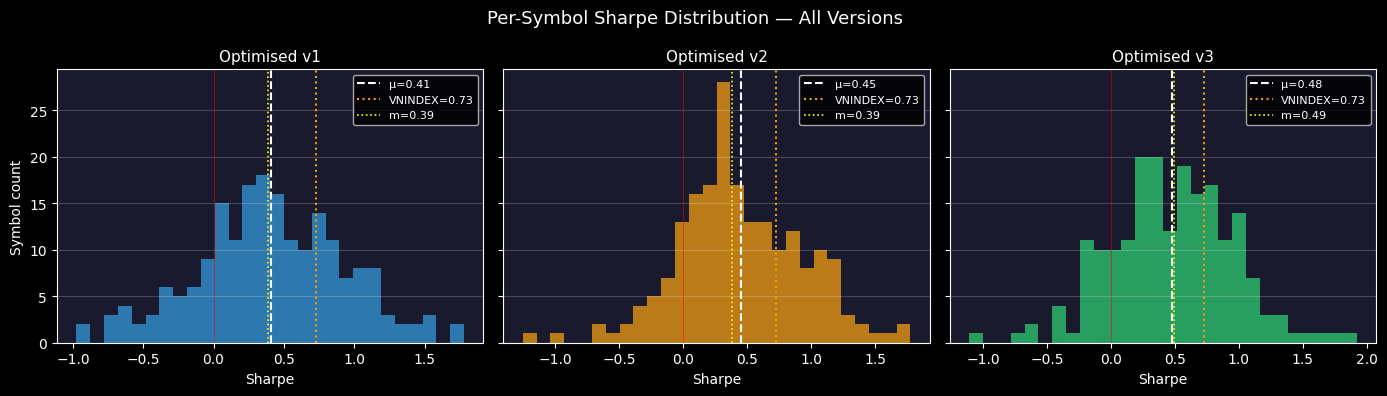

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

entries_list = [(f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']]
bh_sharpe_ref = float(np.atleast_1d(pf_base.sharpe_ratio())[0])

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--',
               label=f'μ={sv.mean():.2f}')
    ax.axvline(bh_sharpe_ref, color='#f39c12', lw=1.5, ls=':',
               label=f'VNINDEX={bh_sharpe_ref:.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
               label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


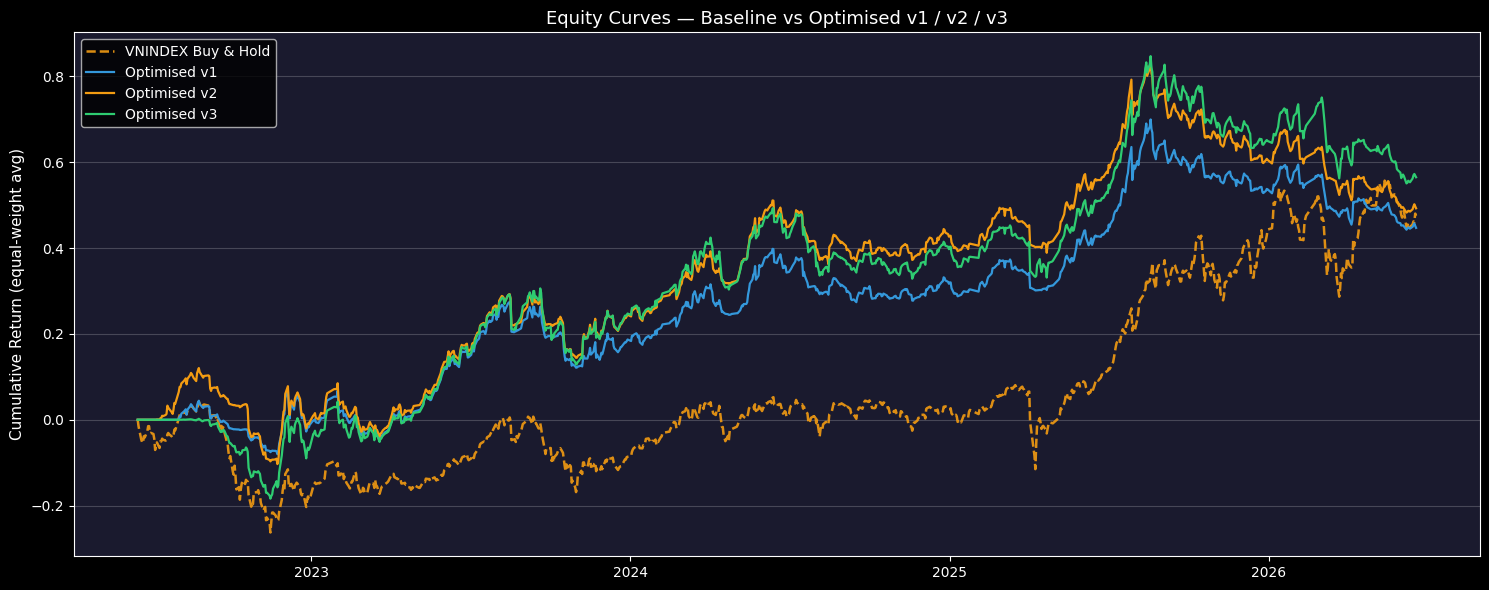

In [99]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

# pf_base is single-symbol: cumulative_returns() returns a Series, not DataFrame
_bh_cum = pf_base.cumulative_returns()
bh_cum = _bh_cum if isinstance(_bh_cum, pd.Series) else _bh_cum.mean(axis=1)
ax.plot(bh_cum.index, bh_cum.values,
        color='#f39c12', lw=1.8, ls='--', label='VNINDEX Buy & Hold', alpha=0.9)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()

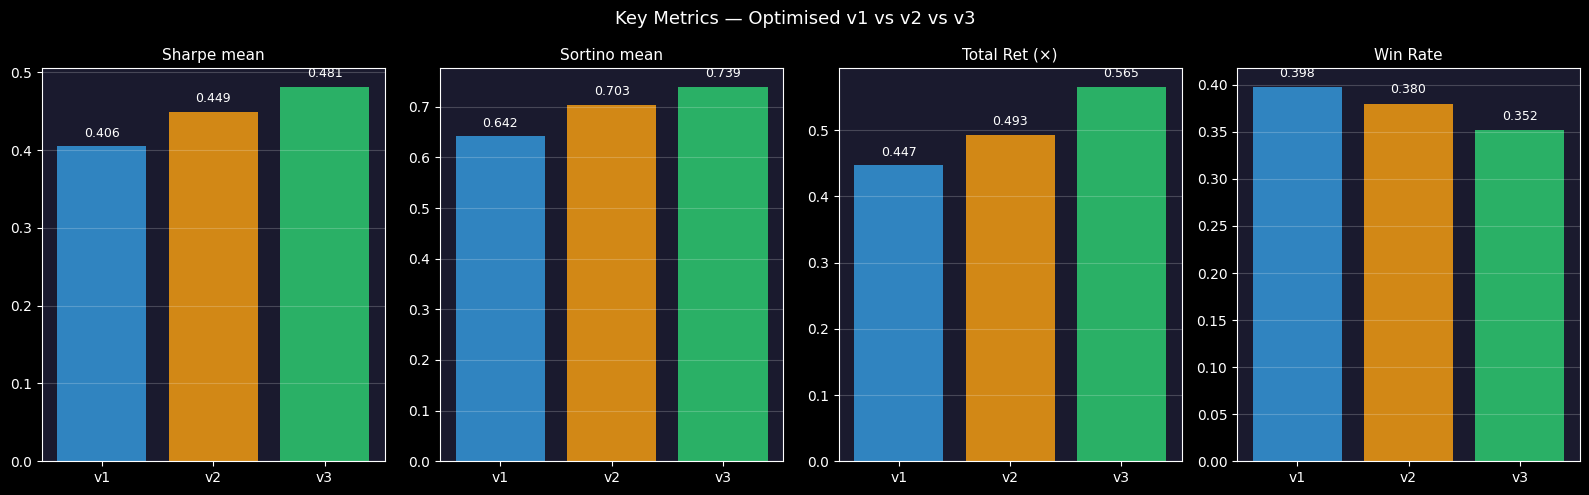

In [100]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


In [101]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

bh_sh = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_so = float(np.atleast_1d(pf_base.sortino_ratio())[0])
bh_tr = float(np.atleast_1d(pf_base.total_return())[0])
print(f'  {"VNINDEX B&H":<12}  {bh_sh:>9.3f}  {bh_so:>10.3f}  {bh_tr:>11.1%}  {"N/A":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  VNINDEX B&H       0.730       0.983        47.5%        N/A
  ----------------------------------------------------------
  v1                0.406       0.642         44.7%      39.8%
  v2                0.449       0.703         49.3%      38.0%
  v3                0.481       0.739         56.5%      35.2%

  Best Sharpe  → v3  (0.481)
  Best Return  → v3  (56.5%)
  Best Sortino → v3  (0.739)


## 8. Save Results to HDF5

In [102]:
# Requires: `best_params` from optimisation (Section 5) and `portfolios` from final backtest (Section 6).
SAVE_VER = 'v1'  # 'v1' | 'v2' | 'v3' — which optimised run to export
pf_opt = portfolios[SAVE_VER]
best = best_params[SAVE_VER]

h5_file   = '../backend/assets/backtest_results_005.h5'
close_syms = set(close.columns)

# ── trades ────────────────────────────────────────────────────────────────────
trades_df = pf_opt.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp']).dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp']).dt.strftime('%Y-%m-%d')

# ── per-symbol stats ──────────────────────────────────────────────────────────
all_metrics = list(pf_opt.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_opt.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# ── best params ───────────────────────────────────────────────────────────────
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file, key='trades',     mode='w')
stats_df.to_hdf(h5_file,  key='stats',      mode='a')
params_df.to_hdf(h5_file, key='best_params', mode='a')

import json
_ttm_json = '../backend/assets/ttm_best_params_005.json'
with open(_ttm_json, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f'Saved TTM best params (v1/v2/v3) →  {_ttm_json}')

print(f'Saved {len(trades_df):,} trades  →  {h5_file}')
print(f'Saved stats for {len(stats_df)} symbols')
print(f'Saved best params ({len(best)} keys)')

trades_df.head()

Saved TTM best params (v1/v2/v3) →  ../backend/assets/ttm_best_params_005.json
Saved 4,227 trades  →  ../backend/assets/backtest_results_005.h5
Saved stats for 198 symbols
Saved best params (13 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(13, 2.3, 6, AAA)",8.230453,2022-08-02,12.15,0.0,2022-08-29,11.43,0.0,-5.925926,-0.059259,Long,Closed,0,AAA
1,1,"(13, 2.3, 6, AAA)",14.082945,2022-11-22,6.68,0.0,2022-12-26,6.41,0.0,-3.802395,-0.040419,Long,Closed,1,AAA
2,2,"(13, 2.3, 6, AAA)",13.159137,2023-01-06,6.86,0.0,2023-02-13,7.49,0.0,8.290256,0.091837,Long,Closed,2,AAA
3,3,"(13, 2.3, 6, AAA)",11.554740,2023-02-20,8.53,0.0,2023-06-16,10.32,0.0,20.682985,0.209848,Long,Closed,3,AAA
4,4,"(13, 2.3, 6, AAA)",10.889947,2023-07-06,10.95,0.0,2023-08-18,10.51,0.0,-4.791577,-0.040183,Long,Closed,4,AAA


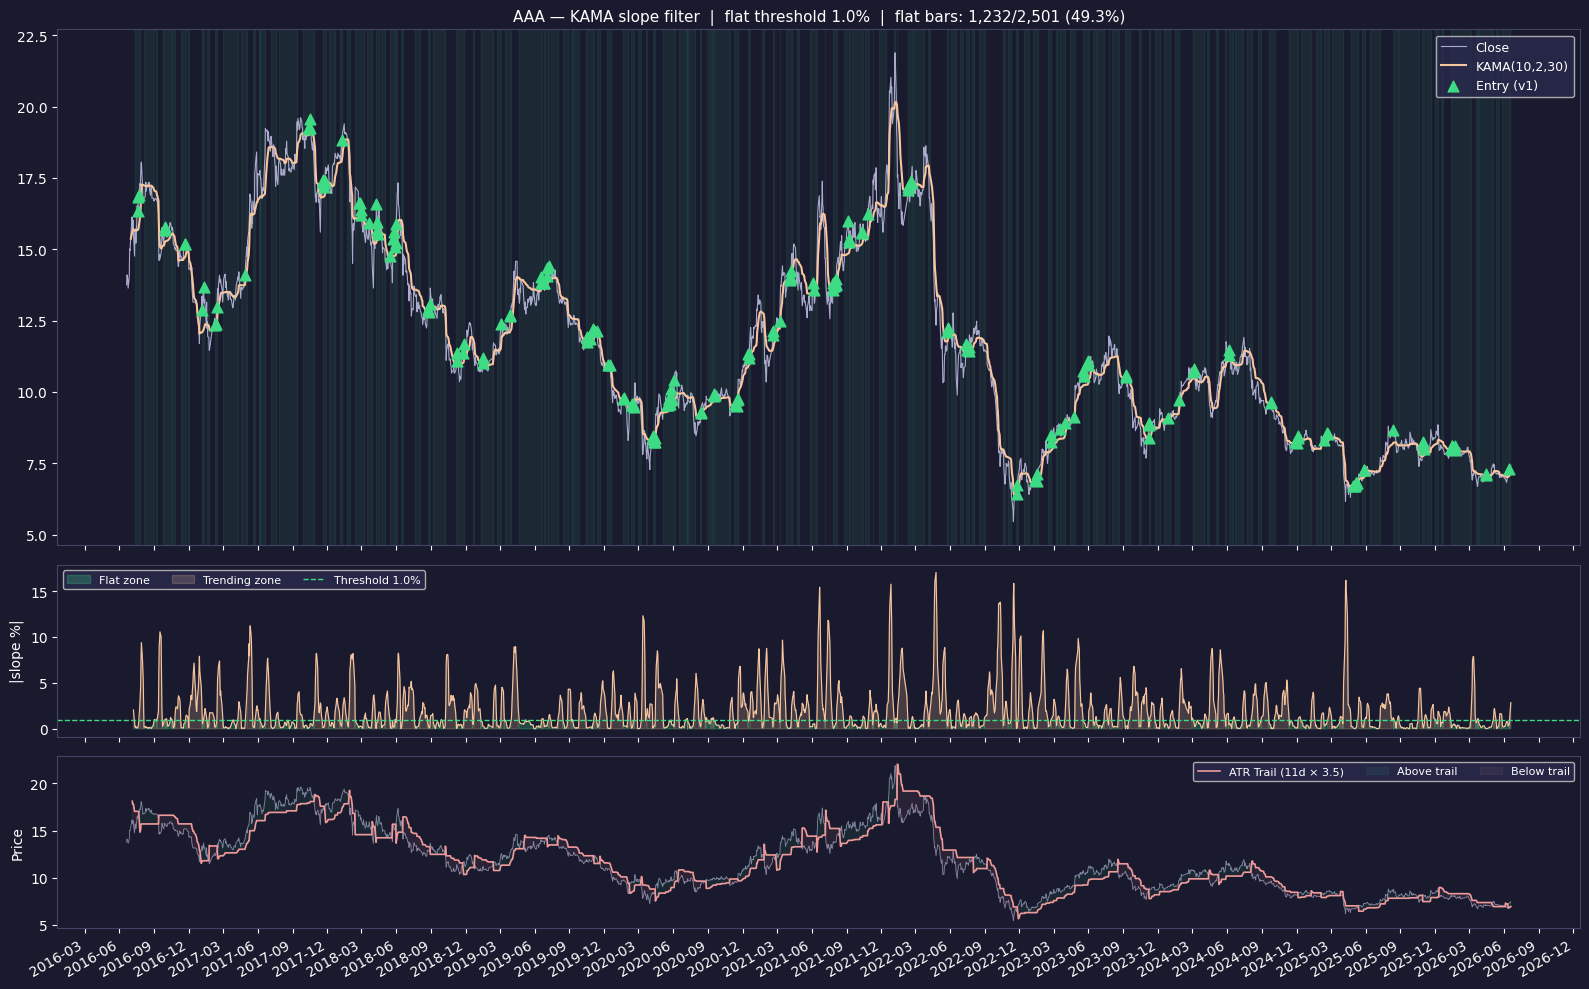

Entry signals (v1): 195 signals on AAA


In [103]:
# ── KAMA Slope Visual Inspection ─────────────────────────────────────────────
# Panel 1: Close price + KAMA line + flat-slope shading + entry signals
# Panel 2: |KAMA slope %| with flatness threshold
# Panel 3: ATR trailing stop
# Run Section 2 (helpers) first so kama_2d / slope_flat_2d are defined.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ── Config — edit these ───────────────────────────────────────────────────────
INSPECT_SYM    = close.columns[0]   # symbol to inspect
KAMA_PERIOD    = 10
KAMA_FAST      = 2
KAMA_SLOW      = 30
SLOPE_WIN      = 5
FLAT_PCT       = 1.0
ATR_PERIOD     = 11
ATR_MULT       = 3.5
SHOW_ENTRIES   = True               # overlay entry signals on price chart
ENTRY_VERSION  = 'v1'               # 'v1' | 'v2' | 'v3'
# ─────────────────────────────────────────────────────────────────────────────

close_1d = close[[INSPECT_SYM]].to_numpy().astype(np.float64)
high_1d  = high [[INSPECT_SYM]].to_numpy().astype(np.float64)
low_1d   = low  [[INSPECT_SYM]].to_numpy().astype(np.float64)

kama_np = kama_2d(close_1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
flat_np = slope_flat_2d(kama_np, SLOPE_WIN, FLAT_PCT)
flat_mask = flat_np[:, 0]

# ATR trailing stop (reuse trailing_sl from backend)
from backend.app.services.indicators.trailing_sl import trailing_sl
import talib as _talib

atr_raw   = _talib.ATR(high_1d[:, 0], low_1d[:, 0], close_1d[:, 0], timeperiod=ATR_PERIOD)
atr_trail = trailing_sl(close_1d[:, 0], atr_raw, atr_multiplier=ATR_MULT)

# Entry signals for this symbol
if SHOW_ENTRIES:
    _entries_df = compute_signals(
        close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]],
        entry_version=ENTRY_VERSION,
        use_kama_slope=True,
        kama_period=KAMA_PERIOD, kama_fast=KAMA_FAST, kama_slow=KAMA_SLOW,
        kama_slope_win=SLOPE_WIN, flat_threshold_pct=FLAT_PCT,
    )
    entry_dates = _entries_df.index[_entries_df[INSPECT_SYM].values]
    entry_prices = close[INSPECT_SYM].reindex(entry_dates).values

# pct slope
pct_slope = np.full(len(kama_np), np.nan)
for i in range(SLOPE_WIN, len(kama_np)):
    prev = kama_np[i - SLOPE_WIN, 0]
    if prev != 0 and not np.isnan(prev):
        pct_slope[i] = abs((kama_np[i, 0] - prev) / prev * 100.0)

# ── Plot ──────────────────────────────────────────────────────────────────────
idx_range = close.index
DARK = '#1a1a2e'

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor(DARK)
for ax in axes:
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white')
    ax.yaxis.label.set_color('white')

ax1, ax2, ax3 = axes

# ── Panel 1: Price + KAMA + flat shading + entries ───────────────────────────
# Flat-slope shading (vectorised for speed)
flat_changes = np.where(np.diff(flat_mask.astype(int)) != 0)[0] + 1
boundaries   = [0] + list(flat_changes) + [len(flat_mask)]
for start, end in zip(boundaries[:-1], boundaries[1:]):
    if flat_mask[start]:
        ax1.axvspan(idx_range[start], idx_range[min(end, len(idx_range)-1)],
                    color='#3ddc84', alpha=0.08)

ax1.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.8, label='Close')
ax1.plot(idx_range, kama_np[:, 0], color='#f7c59f', lw=1.5,
         label=f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW})')

if SHOW_ENTRIES and len(entry_dates):
    ax1.scatter(entry_dates, entry_prices, marker='^', color='#3ddc84',
                s=60, zorder=5, label=f'Entry ({ENTRY_VERSION})')

ax1.set_title(
    f'{INSPECT_SYM} — KAMA slope filter  |  flat threshold {FLAT_PCT}%  |  '
    f'flat bars: {flat_mask.sum():,}/{len(flat_mask):,} ({flat_mask.mean()*100:.1f}%)',
    color='white', fontsize=11,
)
ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

# ── Panel 2: |KAMA slope %| ───────────────────────────────────────────────────
above = pct_slope >= FLAT_PCT
ax2.fill_between(idx_range, pct_slope, 0,
                 where=~above, color='#3ddc84', alpha=0.25, label='Flat zone')
ax2.fill_between(idx_range, pct_slope, 0,
                 where=above,  color='#f7c59f', alpha=0.20, label='Trending zone')
ax2.plot(idx_range, pct_slope, color='#f7c59f', lw=0.8)
ax2.axhline(FLAT_PCT, color='#3ddc84', lw=1, ls='--', label=f'Threshold {FLAT_PCT}%')
ax2.set_ylabel('|slope %|', color='white')
ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

# ── Panel 3: ATR trailing stop ────────────────────────────────────────────────
ax3.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.6, alpha=0.7)
ax3.plot(idx_range, atr_trail, color='#ef9a9a', lw=1.2, label=f'ATR Trail ({ATR_PERIOD}d × {ATR_MULT})')
above_trail = close[INSPECT_SYM].values > atr_trail
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=above_trail,  color='#3ddc84', alpha=0.07, label='Above trail')
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=~above_trail, color='#ef9a9a', alpha=0.07, label='Below trail')
ax3.set_ylabel('Price', color='white')
ax3.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

# ── X axis ────────────────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

plt.tight_layout()
plt.show()

if SHOW_ENTRIES:
    print(f"Entry signals ({ENTRY_VERSION}): {len(entry_dates)} signals on {INSPECT_SYM}")


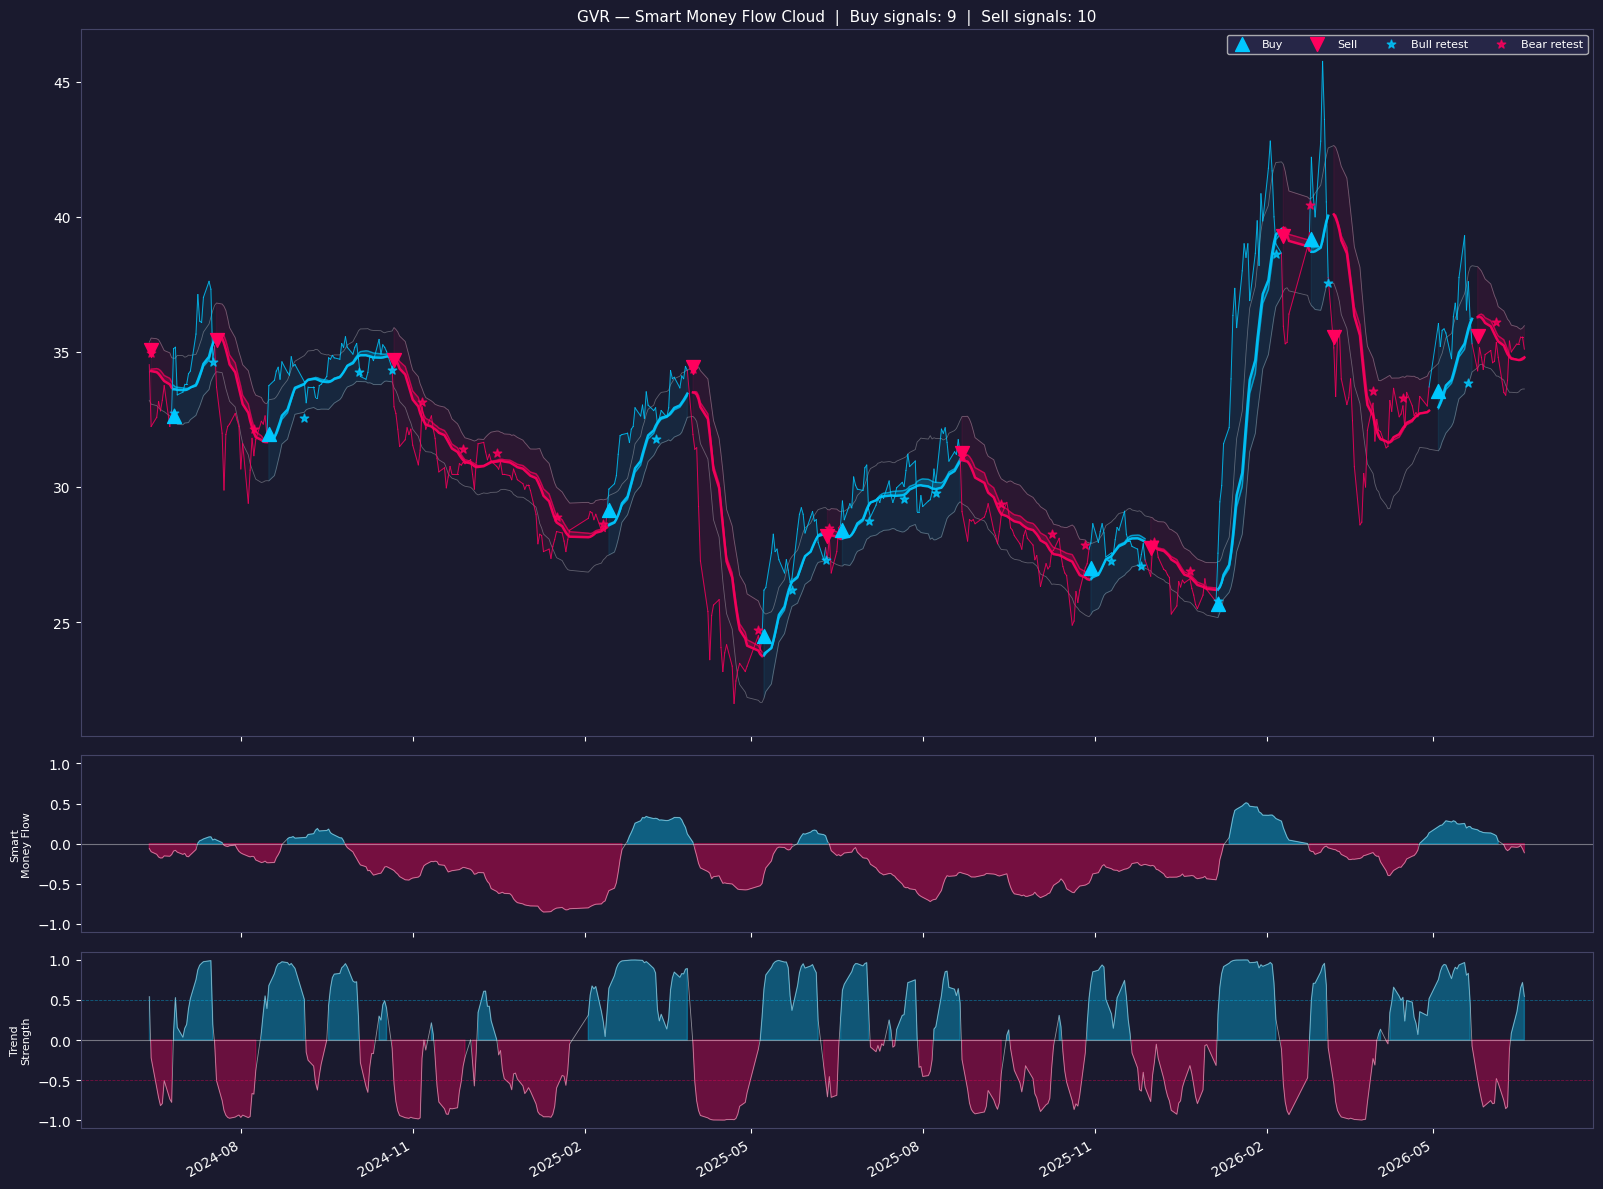


GVR — Latest readings:
  Regime   : BEAR 🔴
  MF Flow  : -0.114
  Strength : 7.4%
  Upper    : 35.97  |  Lower: 33.63
  Trend str: +0.543


In [131]:
# ── Smart Money Flow Cloud — Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
# INSPECT_SYM  = close.columns[0]   # symbol to inspect
TREND_LEN    = 34
BASIS_TYPE_DEFAULT   = 'EMA'              # 'EMA' | 'ALMA'
BASIS_SMOOTH = 3
MF_LEN       = 24
MF_SMOOTH    = 5
MF_POWER     = 1.2
ATR_LEN      = 14
MIN_MULT     = 0.9
MAX_MULT     = 2.2
DOT_COOLDOWN = 12
LOOKBACK     = 504                # bars to show (None = all)
# ─────────────────────────────────────────────────────────────────────────────
def display_smf_cloud(symbol, basis_type=BASIS_TYPE_DEFAULT):

    # Compute for single symbol
    _res = smart_money_flow_cloud(
        open_[[symbol]], high[[symbol]], low[[symbol]],
        close[[symbol]], volume[[symbol]],
        trend_len=TREND_LEN, basis_type=basis_type, basis_smooth=BASIS_SMOOTH,
        mf_len=MF_LEN, mf_smooth=MF_SMOOTH, mf_power=MF_POWER,
        atr_len=ATR_LEN, min_mult=MIN_MULT, max_mult=MAX_MULT,
        dot_cooldown=DOT_COOLDOWN,
    )[symbol]

    # Slice to LOOKBACK
    if LOOKBACK:
        sl = slice(-LOOKBACK, None)
        _r = {k: v.iloc[sl] for k, v in _res.items()}
        _c = close[symbol].iloc[sl]
        _h = high[symbol].iloc[sl]
        _l = low[symbol].iloc[sl]
    else:
        _r = _res
        _c = close[symbol]
        _h = high[symbol]
        _l = low[symbol]

    idx = _c.index
    sig = _r['last_signal'].values
    BULL_C, BEAR_C = '#00C8FF', '#FF005D'
    DARK = '#1a1a2e'

    # ── Plot ──────────────────────────────────────────────────────────────────────
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1, 1]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values(): sp.set_color('#444466')
        ax.tick_params(colors='white')

    # ── Panel 1: Price + Cloud + Bands ───────────────────────────────────────────
    # Basis cloud fill (b_open to b_close), colored by regime
    bull_mask = sig == 1
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        ax1.fill_between(idx, _r['b_open'], _r['b_close'],
                        where=mask, color=color, alpha=0.25, label='_')

    # Adaptive band fills (price vs bands)
    above_lower = _c.values > _r['lower'].values
    below_upper = _c.values < _r['upper'].values
    ax1.fill_between(idx, _c, _r['lower'],
                    where=bull_mask & above_lower, color=BULL_C, alpha=0.08)
    ax1.fill_between(idx, _c, _r['upper'],
                    where=(~bull_mask) & below_upper, color=BEAR_C, alpha=0.08)

    # Band lines
    ax1.plot(idx, _r['upper'], color='white', lw=0.6, alpha=0.3)
    ax1.plot(idx, _r['lower'], color='white', lw=0.6, alpha=0.3)

    # Basis lines (colored by regime)
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        masked_c = np.where(mask, _r['b_close'].values, np.nan)
        masked_o = np.where(mask, _r['b_open'].values,  np.nan)
        ax1.plot(idx, masked_c, color=color, lw=1.8, alpha=0.9)
        ax1.plot(idx, masked_o, color=color, lw=1.0, alpha=0.6)

    # Price line (color-segmented by regime)
    for i in range(1, len(idx)):
        c = BULL_C if sig[i] == 1 else BEAR_C
        ax1.plot(idx[i-1:i+1], _c.values[i-1:i+1], color=c, lw=0.7, alpha=0.8)

    # Buy/Sell labels
    atr_off = (_r['upper'] - _r['lower']).values * 0.08
    up_idx  = np.where(_r['switch_up'].values)[0]
    dn_idx  = np.where(_r['switch_down'].values)[0]
    ax1.scatter(idx[up_idx], _l.values[up_idx] - atr_off[up_idx],
                marker='^', color=BULL_C, s=100, zorder=6, label='Buy')
    ax1.scatter(idx[dn_idx], _h.values[dn_idx] + atr_off[dn_idx],
                marker='v', color=BEAR_C, s=100, zorder=6, label='Sell')

    # Retest dots
    bull_d = np.where(_r['bull_dot'].values)[0]
    bear_d = np.where(_r['bear_dot'].values)[0]
    ax1.scatter(idx[bull_d], _l.values[bull_d] - atr_off[bull_d] * 0.5,
                marker='*', color=BULL_C, s=40, alpha=0.8, zorder=5, label='Bull retest')
    ax1.scatter(idx[bear_d], _h.values[bear_d] + atr_off[bear_d] * 0.5,
                marker='*', color=BEAR_C, s=40, alpha=0.8, zorder=5, label='Bear retest')

    n_buy = len(up_idx); n_sell = len(dn_idx)
    ax1.set_title(
        f'{symbol} — Smart Money Flow Cloud  |  '
        f'Buy signals: {n_buy}  |  Sell signals: {n_sell}',
        color='white', fontsize=11,
    )
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4)

    # ── Panel 2: Smart Money Flow ─────────────────────────────────────────────────
    mf_vals = _r['mf_smooth'].values
    ax2.fill_between(idx, mf_vals, 0,
                    where=mf_vals >= 0, color=BULL_C, alpha=0.4)
    ax2.fill_between(idx, mf_vals, 0,
                    where=mf_vals < 0,  color=BEAR_C, alpha=0.4)
    ax2.plot(idx, mf_vals, color='white', lw=0.6, alpha=0.5)
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax2.set_ylabel('Smart\nMoney Flow', color='white', fontsize=8)
    ax2.set_ylim(-1.1, 1.1)

    # ── Panel 3: Trend Strength (signed tanh) ────────────────────────────────────
    str_vals = _r['strength_signed'].values
    ax3.fill_between(idx, str_vals, 0,
                    where=str_vals >= 0, color=BULL_C, alpha=0.35)
    ax3.fill_between(idx, str_vals, 0,
                    where=str_vals < 0,  color=BEAR_C, alpha=0.35)
    ax3.plot(idx, str_vals, color='white', lw=0.6, alpha=0.5)
    ax3.axhline( 0,    color='white',  lw=0.8, alpha=0.4)
    ax3.axhline( 0.5,  color=BULL_C,  lw=0.6, ls='--', alpha=0.4)
    ax3.axhline(-0.5,  color=BEAR_C,  lw=0.6, ls='--', alpha=0.4)
    ax3.set_ylabel('Trend\nStrength', color='white', fontsize=8)
    ax3.set_ylim(-1.1, 1.1)

    # ── X axis ────────────────────────────────────────────────────────────────────
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

    plt.tight_layout()
    plt.show()

    # Latest reading summary
    cur_sig = "BULL 🟢" if _r['last_signal'].iloc[-1] == 1 else "BEAR 🔴"
    print(f"\n{symbol} — Latest readings:")
    print(f"  Regime   : {cur_sig}")
    print(f"  MF Flow  : {_r['mf_smooth'].iloc[-1]:+.3f}")
    print(f"  Strength : {_r['strength'].iloc[-1]:.1%}")
    print(f"  Upper    : {_r['upper'].iloc[-1]:,.2f}  |  Lower: {_r['lower'].iloc[-1]:,.2f}")
    print(f"  Trend str: {_r['strength_signed'].iloc[-1]:+.3f}")


display_smf_cloud('GVR', basis_type='ALMA')